In [1]:
#################################
#
# K - MEDOIDS CLUSTERING
#
#################################
#
# K-medoids -> partition data into k disjoint sets by minimizing sum of distances to representative points (medoids)
# Its not -> probabilistic modeling, density estimation, representation learning, centroid-based clustering
# Assumption -> distance metric meaningfully captures similarity, clusters are roughly separable, medoids are good representatives
#
# Given data matrix X belongs to R (samples x features) and chosen k
# We want medoids m_1,...,m_k where each m_j is an actual data point
# Objective -> min sum_i d(x_i, m_{c(i)})
#
# Algorithm 
# Initialization -> randomly choose k data points as medoids
# Assignment step -> assign each point to nearest medoid
# Update step -> for each cluster, choose point minimizing total intra-cluster distance
# Repeat until medoids stabilize or max iterations reached
#
# Geometry / interpretation
# Produces Voronoi-like partitions under the chosen distance metric
# Boundaries depend on metric, not necessarily perpendicular bisectors
# Optimizes robustness over compactness
#
# Compared to k-means
# Uses medians / representatives instead of means
# Robust to outliers
# Works with arbitrary distance metrics
# Slower due to combinatorial medoid updates
#
# Limitations
# Still fails on non-convex clusters
# Sensitive to initialization
# Struggles with overlapping clusters
# Computationally expensive for large datasets
#


In [2]:
import numpy as np
import matplotlib.pyplot as plt 
def k_medoids(X, k, max_iters=100):
    medoids_idx = np.random.choice(len(X), k, replace=False)
    for _ in range(max_iters):
        distances = np.sqrt(((X[:, np.newaxis] - X[medoids_idx]) ** 2).sum(axis=2))
        labels = np.argmin(distances, axis=1)
        new_medoids_idx = []
        for i in range(k):
            cluster_points = X[labels == i]
            dists = np.sqrt(((cluster_points[:, np.newaxis] - cluster_points) ** 2).sum(axis=2))
            new_medoids_idx.append(np.where(labels == i)[0][np.argmin(dists.sum(axis=1))])
        new_medoids_idx = np.array(new_medoids_idx)
        if np.array_equal(medoids_idx, new_medoids_idx):
            break
        medoids_idx = new_medoids_idx
    return labels, X[medoids_idx]

######################### K-Medoids ##############################

k : 3

Final medoids:
[[ 1.87122261  1.65580289]
 [-2.04780237 -1.69686678]
 [ 1.83636269 -2.13813098]]

Cluster sizes: 
[103 101  96]



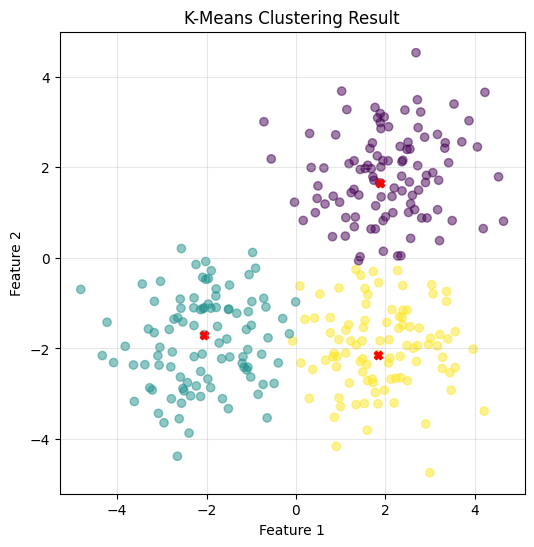

In [3]:
X = np.vstack([np.random.randn(100, 2) + [2, 2],
               np.random.randn(100, 2) + [-2, -2],
               np.random.randn(100, 2) + [2, -2]])
k = 3
labels_medoids, medoids= k_medoids(X, k)

print("######################### K-Medoids ##############################")
print()
print(f"k : {k}")
print()
print(f"Final medoids:\n{medoids}")
print()
print(f"Cluster sizes: \n{np.bincount(labels_medoids)}")
print()
plt.figure(figsize=(6, 6))
plt.scatter(X[:,0], X[:,1], c=labels_medoids, cmap='viridis',alpha=0.5)
plt.scatter(medoids[:, 0], medoids[:, 1], c='red', marker='X')
plt.title('K-Means Clustering Result')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.show()


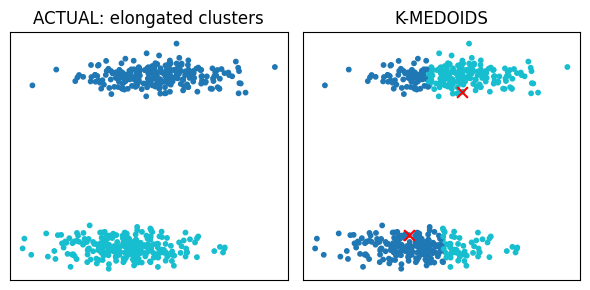

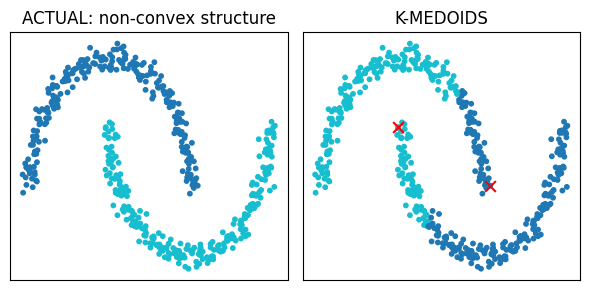

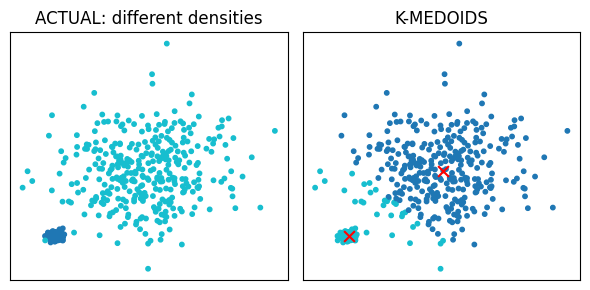

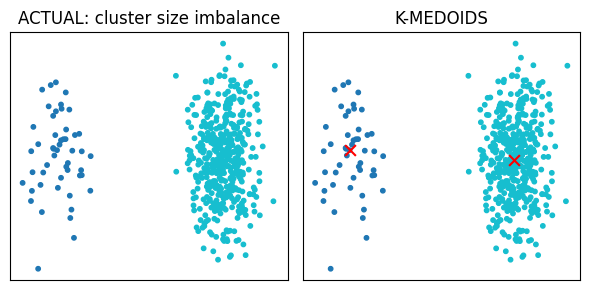

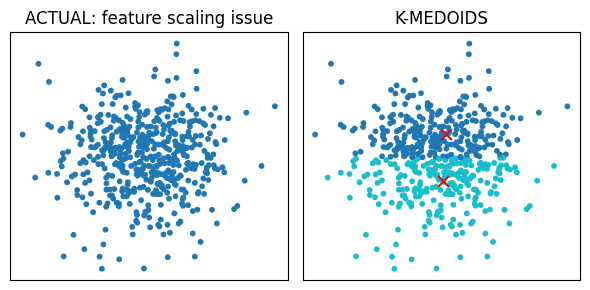

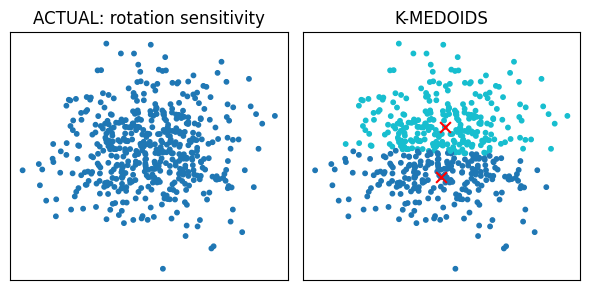

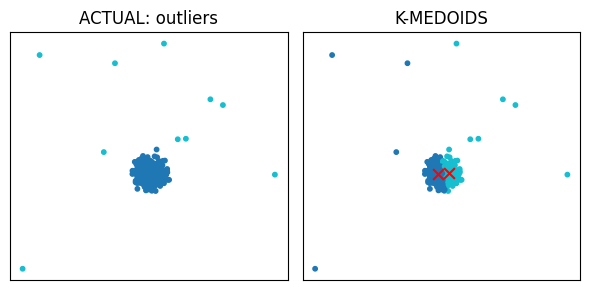

In [4]:
np.random.seed(42)
n_samples = 500

############################
# 1. ELONGATED / ANISOTROPIC CLUSTERS
# distance captures similarity but medoids cannot model shape
############################
X_elongated = np.vstack([
    np.random.randn(n_samples//2, 2) @ np.array([[5, 0], [0, 0.2]]) + [2, 2],
    np.random.randn(n_samples//2, 2) @ np.array([[5, 0], [0, 0.2]]) + [-2, -2]
])
y_elongated = np.hstack([
    np.zeros(n_samples//2, dtype=int),
    np.ones(n_samples//2, dtype=int)
])

############################
# 2. NON-CONVEX CLUSTERS (TWO MOONS)
# Voronoi-style partitions fail on curved manifolds
############################
theta = np.linspace(0, np.pi, n_samples//2)
moon1 = np.c_[np.cos(theta), np.sin(theta)]
moon2 = np.c_[1 - np.cos(theta), 1 - np.sin(theta) - 0.5]
X_nonconvex = np.vstack([moon1, moon2]) + 0.05 * np.random.randn(n_samples, 2)
y_nonconvex = np.hstack([
    np.zeros(n_samples//2, dtype=int),
    np.ones(n_samples//2, dtype=int)
])

############################
# 3. DIFFERENT DENSITIES
# medoids drift toward dense regions
############################
dense = 0.2 * np.random.randn(n_samples//3, 2) + [0, 0]
sparse = 2.5 * np.random.randn(2*n_samples//3, 2) + [5, 5]
X_density = np.vstack([dense, sparse])
y_density = np.hstack([
    np.zeros(n_samples//3, dtype=int),
    np.ones(2*n_samples//3, dtype=int)
])

############################
# 4. DIFFERENT CLUSTER SIZES
# medoids biased toward larger clusters
############################
small = np.random.randn(50, 2) + [-5, 0]
large = np.random.randn(450, 2) + [5, 0]
X_size_imbalance = np.vstack([small, large])
y_size_imbalance = np.hstack([
    np.zeros(50, dtype=int),
    np.ones(450, dtype=int)
])

############################
# 5. SCALE SENSITIVITY
# metric dominated by large-scale feature
############################
X_scaled = np.random.randn(n_samples, 2)
X_scaled[:, 1] *= 100
y_scaled = np.zeros(n_samples, dtype=int)

############################
# 6. ROTATION SENSITIVITY
# geometry changes under rotation
############################
X_base = np.random.randn(n_samples, 2)
R = np.array([[0.7, -0.7],
              [0.7,  0.7]])
X_rotated = X_base @ R
y_rotated = np.zeros(n_samples, dtype=int)

############################
# 7. OUTLIERS
# k-medoids is robust, but cluster structure still degrades
############################
X_outliers = np.random.randn(n_samples, 2)
outliers = np.random.uniform(low=-20, high=20, size=(10, 2))
X_outliers = np.vstack([X_outliers, outliers])
y_outliers = np.hstack([
    np.zeros(n_samples, dtype=int),
    np.ones(10, dtype=int)
])

test_cases = [
    ("elongated clusters", X_elongated, y_elongated),
    ("non-convex structure", X_nonconvex, y_nonconvex),
    ("different densities", X_density, y_density),
    ("cluster size imbalance", X_size_imbalance, y_size_imbalance),
    ("feature scaling issue", X_scaled, y_scaled),
    ("rotation sensitivity", X_rotated, y_rotated),
    ("outliers", X_outliers, y_outliers),
]

k = 2

for name, X, y_true in test_cases:
    labels, medoids = k_medoids(X, k)

    fig, ax = plt.subplots(1, 2, figsize=(6, 3))

    ax[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap="tab10", s=10)
    ax[0].set_title(f"ACTUAL: {name}")
    ax[0].set_xticks([])
    ax[0].set_yticks([])

    ax[1].scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=10)
    ax[1].scatter(
        medoids[:, 0], medoids[:, 1],
        c="red", marker="x", s=60
    )
    ax[1].set_title("K-MEDOIDS")
    ax[1].set_xticks([])
    ax[1].set_yticks([])

    plt.tight_layout()
    plt.show()